# AI Customer Review Sentiment Analyzer

## Project 5 — AI Automation Portfolio

This project uses Python, Prompt Engineering, Data Analysis, and the OpenAI API to analyze customer reviews and generate structured customer insights.

The AI identifies:

* Overall sentiment
* Positive feedback
* Negative feedback
* Customer concerns
* Key themes
* Suggested business actions


## Project Goal

The goal of this project is to automate customer-feedback analysis by converting unstructured customer reviews into clear sentiment classifications, meaningful themes, and actionable business insights.


## Step 2: Customer Review Analysis and Prompt Design

In this section, sample customer reviews are prepared and inserted into a structured AI prompt. The prompt instructs the AI to classify sentiment, identify positive and negative feedback, extract customer themes, and generate actionable business insights.


In [1]:
# Sample customer reviews

customer_reviews = [
    {
        "review_id": 1,
        "review": """
        The wireless headphones are comfortable and the sound is clear.
        The battery lasted through my workday, and the controls were easy
        to use. I would recommend them to other remote workers.
        """
    },
    {
        "review_id": 2,
        "review": """
        The backpack has plenty of storage space and the laptop compartment
        is useful. However, the shoulder straps became uncomfortable during
        a long commute.
        """
    },
    {
        "review_id": 3,
        "review": """
        The product arrived on time and works as described. The setup was
        straightforward, but I have not used it long enough to form a strong
        opinion.
        """
    },
    {
        "review_id": 4,
        "review": """
        The desk lamp stopped working after a few days. The brightness was
        useful while it worked, but the product did not meet my expectations.
        """
    }
]

print("Number of customer reviews:", len(customer_reviews))

Number of customer reviews: 4


In [2]:
# Display the sample customer reviews

for item in customer_reviews:
    print(f"\nReview ID: {item['review_id']}")
    print(item["review"])


Review ID: 1

        The wireless headphones are comfortable and the sound is clear.
        The battery lasted through my workday, and the controls were easy
        to use. I would recommend them to other remote workers.
        

Review ID: 2

        The backpack has plenty of storage space and the laptop compartment
        is useful. However, the shoulder straps became uncomfortable during
        a long commute.
        

Review ID: 3

        The product arrived on time and works as described. The setup was
        straightforward, but I have not used it long enough to form a strong
        opinion.
        

Review ID: 4

        The desk lamp stopped working after a few days. The brightness was
        useful while it worked, but the product did not meet my expectations.
        


## Create a Structured Review Dataset

In [3]:
# Convert the customer reviews into a structured text format

reviews_text = ""

for item in customer_reviews:
    reviews_text += f"""
Review ID: {item['review_id']}

Customer Review:
{item['review']}

------------------------------
"""

print(reviews_text)


Review ID: 1

Customer Review:

        The wireless headphones are comfortable and the sound is clear.
        The battery lasted through my workday, and the controls were easy
        to use. I would recommend them to other remote workers.
        

------------------------------

Review ID: 2

Customer Review:

        The backpack has plenty of storage space and the laptop compartment
        is useful. However, the shoulder straps became uncomfortable during
        a long commute.
        

------------------------------

Review ID: 3

Customer Review:

        The product arrived on time and works as described. The setup was
        straightforward, but I have not used it long enough to form a strong
        opinion.
        

------------------------------

Review ID: 4

Customer Review:

        The desk lamp stopped working after a few days. The brightness was
        useful while it worked, but the product did not meet my expectations.
        

----------------------------

## Design the AI Sentiment-Analysis Prompt

In [4]:
# Create a structured prompt for customer-review sentiment analysis

prompt = f"""
You are an expert customer-insights analyst, sentiment-analysis
specialist, e-commerce analyst, and business intelligence assistant.

Your task is to analyze the customer reviews provided below and
generate accurate, evidence-based, and actionable insights.

CUSTOMER REVIEWS

{reviews_text}

SENTIMENT CATEGORIES

Classify each review as exactly one of the following:

- Positive
- Negative
- Neutral
- Mixed

Use these definitions:

Positive:
The review is mainly favorable and expresses satisfaction,
approval, or a positive customer experience.

Negative:
The review is mainly unfavorable and expresses dissatisfaction,
complaints, frustration, or a negative customer experience.

Neutral:
The review is mainly factual, informational, or balanced without
a clear positive or negative emotional direction.

Mixed:
The review contains both meaningful positive and negative feedback.

ANALYSIS RULES

1. Analyze each review separately.
2. Use only information stated or clearly supported by the review.
3. Do not invent product details, customer experiences, or business facts.
4. Do not assume a product issue exists unless the customer mentions it.
5. Identify positive aspects only when supported by the review.
6. Identify negative aspects only when supported by the review.
7. Keep the analysis concise and specific.
8. Distinguish customer facts from reasonable business recommendations.
9. If information is missing, do not guess.
10. Do not treat a neutral statement as positive or negative without evidence.
11. Use the exact review ID provided.
12. Provide practical business actions based on the customer feedback.

For each review, provide:

Review ID:
Sentiment:
Sentiment Explanation:
Positive Aspects:
Negative Aspects:
Key Themes:
Customer Concern:
Suggested Business Action:

After analyzing all reviews, provide:

OVERALL BUSINESS INSIGHTS

1. Overall Sentiment Summary
2. Most Common Positive Themes
3. Most Common Negative Themes
4. Main Customer Concerns
5. Recommended Business Priorities
"""

In [5]:
print(prompt)



You are an expert customer-insights analyst, sentiment-analysis
specialist, e-commerce analyst, and business intelligence assistant.

Your task is to analyze the customer reviews provided below and
generate accurate, evidence-based, and actionable insights.

CUSTOMER REVIEWS


Review ID: 1

Customer Review:

        The wireless headphones are comfortable and the sound is clear.
        The battery lasted through my workday, and the controls were easy
        to use. I would recommend them to other remote workers.
        

------------------------------

Review ID: 2

Customer Review:

        The backpack has plenty of storage space and the laptop compartment
        is useful. However, the shoulder straps became uncomfortable during
        a long commute.
        

------------------------------

Review ID: 3

Customer Review:

        The product arrived on time and works as described. The setup was
        straightforward, but I have not used it long enough to form a strong
    

## Step 2.2: AI-Powered Customer Review Analysis

In this section, the structured customer-review prompt is sent to the OpenAI API. The AI analyzes each review, classifies its sentiment, identifies positive and negative feedback, extracts key themes, and generates actionable business insights.


In [ ]:
!pip install -q openai

In [ ]:
# loading the API secquerly
from google.colab import userdata

api_key = userdata.get("OPENAI_API_KEY")

In [ ]:
# Creating client
from openai import OpenAI

client = OpenAI(api_key=api_key)

print("OpenAI client connected successfully.")

## Generate the AI Customer-Review Analysis


In [ ]:
# Send the customer-review prompt to the OpenAI API

response = client.responses.create(
    model="gpt-5-mini",
    input=prompt
)

review_analysis = response.output_text

print(review_analysis)

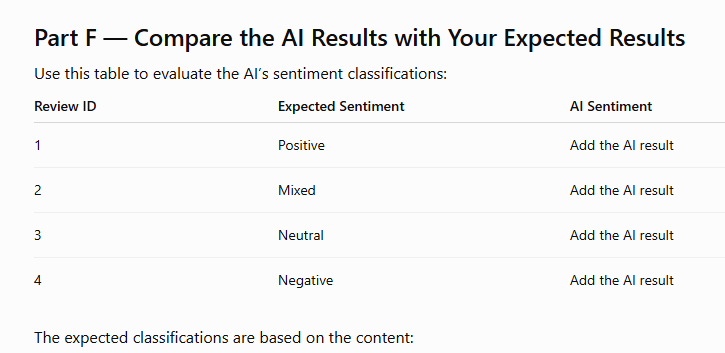

- Review 1: Mainly positive feedback about comfort, sound, battery life, and ease of use.
- Review 2: Positive feedback about storage and the laptop compartment, but negative feedback about strap comfort.
- Review 3: Mostly factual and cautious, without a strong positive or negative opinion.
- Review 4: Mainly negative because the desk lamp stopped working after a few days.

## Quality Check

Review the generated analysis and confirm:

 - All four review IDs are included.
 - Each review has exactly one sentiment category.
 - Review 1 is classified as Positive.
 - Review 2 is classified as Mixed.
 - Review 3 is classified as Neutral.
 - Review 4 is classified as Negative.
 - Positive aspects are supported by the review text.
 - Negative aspects are supported by the review text.
 - Key themes are relevant.
 - Customer concerns are not invented.
 - Business actions are practical and connected to the feedback.
 - Overall insights summarize the four reviews.
 - No unsupported product facts are added.

If one classification differs from our expectation, we will check the AI’s explanation before deciding whether it is incorrect. Sentiment can sometimes be context-dependent, especially for mixed or neutral reviews.

## Test and Refine the Sentiment Analyzer
Part A — Add a New Section
## Testing and Prompt Refinement

In this section, the sentiment analyzer is tested with a new set of customer reviews. The prompt is then refined to improve sentiment consistency, evidence-based analysis, theme extraction, and business recommendations.


In [6]:
# Create a New Test Dataset and Test dataset for sentiment analysis

test_reviews = [
    {
        "review_id": 101,
        "review": """
        I am very happy with this smartwatch. The display is easy to read,
        the activity tracking is useful, and the battery lasts several days.
        It has been a helpful addition to my daily routine.
        """
    },
    {
        "review_id": 102,
        "review": """
        The smartwatch looks good, but the mobile app frequently disconnects.
        I also found the setup instructions difficult to follow.
        """
    },
    {
        "review_id": 103,
        "review": """
        The watch arrived on schedule and the packaging was acceptable.
        I have only used it for one day, so I cannot provide a detailed
        opinion about its performance yet.
        """
    },
    {
        "review_id": 104,
        "review": """
        The display is clear and the watch is comfortable to wear.
        However, the battery drains faster than I expected, and the
        mobile app sometimes stops syncing.
        """
    },
    {
        "review_id": 105,
        "review": """
        The smartwatch stopped charging after one week. Customer support
        took several days to respond, and the issue has not been resolved.
        I am disappointed with both the product and the support experience.
        """
    }
]

print("Number of test reviews:", len(test_reviews))

Number of test reviews: 5


## Predict the Sentiment first
### Expected Sentiment Classifications

| Review ID | Expected Sentiment |
| --------- | ------------------ |
| 101       | Positive           |
| 102       | Mixed              |
| 103       | Neutral            |
| 104       | Mixed              |
| 105       | Negative           |


## Converting the Test Reviews into Structured Text

In [7]:
# Convert test reviews into structured text

test_reviews_text = ""

for item in test_reviews:
    test_reviews_text += f"""
Review ID: {item['review_id']}

Customer Review:
{item['review']}

------------------------------
"""

print(test_reviews_text)


Review ID: 101

Customer Review:

        I am very happy with this smartwatch. The display is easy to read,
        the activity tracking is useful, and the battery lasts several days.
        It has been a helpful addition to my daily routine.
        

------------------------------

Review ID: 102

Customer Review:

        The smartwatch looks good, but the mobile app frequently disconnects.
        I also found the setup instructions difficult to follow.
        

------------------------------

Review ID: 103

Customer Review:

        The watch arrived on schedule and the packaging was acceptable.
        I have only used it for one day, so I cannot provide a detailed
        opinion about its performance yet.
        

------------------------------

Review ID: 104

Customer Review:

        The display is clear and the watch is comfortable to wear.
        However, the battery drains faster than I expected, and the
        mobile app sometimes stops syncing.
        

------

## Create the Refined Sentiment-Analysis Prompt

In [8]:
# Refined prompt for customer-review sentiment analysis

refined_prompt = f"""
You are an expert customer-insights analyst, sentiment-analysis
specialist, e-commerce analyst, and business intelligence assistant.

Your task is to analyze the customer reviews below and generate
consistent, evidence-based, structured, and actionable insights.

CUSTOMER REVIEWS

{test_reviews_text}

SENTIMENT CLASSIFICATION

Assign exactly one sentiment label to each review:

Positive:
The review is mainly favorable and expresses satisfaction,
approval, or a positive customer experience.

Negative:
The review is mainly unfavorable and expresses dissatisfaction,
complaints, frustration, product failure, or a negative
customer experience.

Neutral:
The review is mainly factual, informational, uncertain, or
observational and does not contain a meaningful positive or
negative overall judgment.

Mixed:
The review contains meaningful positive and negative feedback.
Use Mixed when both positive and negative aspects materially
contribute to the customer's overall experience.

CLASSIFICATION RULES

1. Analyze each review independently.
2. Assign exactly one sentiment label.
3. Use only the four allowed labels:
   Positive, Negative, Neutral, or Mixed.
4. Base the sentiment on the customer's overall message,
   not on one isolated word.
5. Use Mixed when both positive and negative feedback are
   meaningful.
6. Do not classify a review as Mixed merely because it contains
   a minor factual detail.
7. Use Neutral when the customer provides limited information
   or does not express a clear overall opinion.
8. Do not invent customer experiences, product details,
   causes, or business facts.
9. Do not infer problems that are not mentioned.
10. Separate evidence from recommendations.
11. Keep the analysis concise and specific.
12. Use the exact review ID provided.

For each review, provide exactly this structure:

Review ID:
Sentiment:
Confidence: High, Medium, or Low

Evidence:
- Include short evidence-based points from the review.

Positive Feedback:
- List supported positive feedback.
- Write "None identified" if no positive feedback is present.

Negative Feedback:
- List supported negative feedback.
- Write "None identified" if no negative feedback is present.

Key Themes:
- List 1 to 3 concise themes.

Customer Concern:
- State the main concern.
- Write "No major concern identified" when appropriate.

Suggested Business Action:
- Provide one practical action.
- Base the action only on the customer feedback.

After analyzing all reviews, provide:

## OVERALL SENTIMENT SUMMARY

- Total reviews analyzed
- Positive review count
- Negative review count
- Neutral review count
- Mixed review count

## COMMON POSITIVE THEMES

List recurring positive themes.

## COMMON NEGATIVE THEMES

List recurring negative themes.

## MAIN CUSTOMER CONCERNS

Identify the most important concerns.

## RECOMMENDED BUSINESS PRIORITIES

Provide 3 prioritized and actionable recommendations.
"""

## Generate the Refined AI Analysis

In [ ]:
response = client.responses.create(
    model="gpt-5-mini",
    input=refined_prompt
)

refined_analysis = response.output_text

print(refined_analysis)

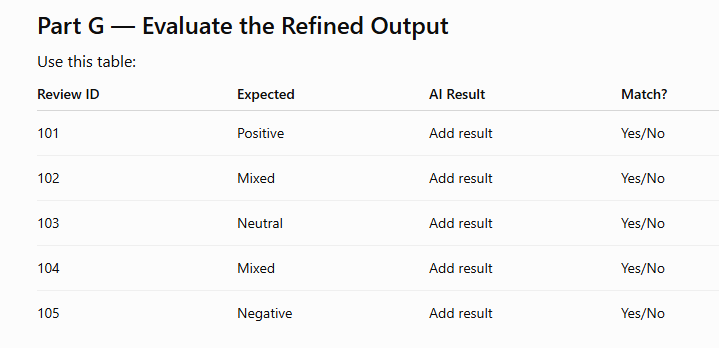

## Step 3.2: Interactive Customer-Review Analyzer

This section allows users to enter a customer review and receive an AI-generated sentiment classification, evidence-based feedback analysis, key themes, customer concerns, and a suggested business action.


In [ ]:
# Collect a customer review from the user

user_review = input(
    "Enter a customer review for analysis:\n\n"
)

print("\nCustomer review received successfully.")

In [ ]:
# The wireless earbuds are comfortable and the sound quality is clear.
# However, the battery drains faster than I expected, and the charging
# case feels less durable than the earbuds themselves.

In [ ]:
# Create a structured prompt for one customer review

interactive_prompt = f"""
You are an expert customer-insights analyst, sentiment-analysis
specialist, e-commerce analyst, and business intelligence assistant.

Analyze the customer review below and generate a concise,
evidence-based, and actionable analysis.

CUSTOMER REVIEW

{user_review}

SENTIMENT LABELS

Assign exactly one sentiment label:

- Positive
- Negative
- Neutral
- Mixed

Use these definitions:

Positive:
The review is mainly favorable and expresses satisfaction,
approval, or a positive customer experience.

Negative:
The review is mainly unfavorable and expresses dissatisfaction,
complaints, frustration, product failure, or a negative
customer experience.

Neutral:
The review is mainly factual, informational, uncertain, or
observational and does not contain a meaningful positive or
negative overall judgment.

Mixed:
The review contains meaningful positive and negative feedback.

ANALYSIS RULES

1. Assign exactly one sentiment label.
2. Base the classification on the customer's overall message.
3. Use only information stated or clearly supported by the review.
4. Do not invent product details, customer experiences,
   causes, or business facts.
5. Use Mixed when both positive and negative feedback are
   meaningful.
6. Do not treat a minor factual detail as a positive or
   negative opinion.
7. If the review contains limited information, explain the
   uncertainty through the confidence level.
8. Keep the analysis concise and specific.
9. Separate evidence from business recommendations.
10. Do not claim that a problem affects all customers based
    on one review.

Use exactly this output structure:

## Sentiment

Sentiment:
Confidence:

## Evidence

- Provide concise evidence from the review.

## Positive Feedback

- List supported positive feedback.
- Write "None identified" if no positive feedback is present.

## Negative Feedback

- List supported negative feedback.
- Write "None identified" if no negative feedback is present.

## Key Themes

- List 1 to 3 concise themes.

## Main Customer Concern

State the main concern.

Write "No major concern identified" when appropriate.

## Suggested Business Action

Provide one practical action based only on the customer feedback.
"""

## Generate the Interactive AI Analysis

In [ ]:
# Generate the AI-powered customer-review analysis

response = client.responses.create(
    model="gpt-5-mini",
    input=interactive_prompt
)

interactive_analysis = response.output_text

print(interactive_analysis)

## Final Quality Check

Confirm that:

 - The user can enter a review without editing Python variables.
 - The review is stored successfully.
 - The AI assigns exactly one sentiment label.
 - The AI provides a confidence level.
 - Positive feedback is supported by the review.
 - Negative feedback is supported by the review.
 - Key themes are relevant.
 - The main concern is based on the review.
 - The business action is practical.
 - No unsupported facts are added.
 - Positive, negative, neutral, and mixed - - reviews are handled correctly.

## Step 3.3: Batch Review Analysis and Sentiment Summary

This section analyzes multiple customer reviews, stores the sentiment results in a structured dataset, and creates a summary of customer sentiment using Python and pandas.


In [1]:
# Final batch of customer reviews

batch_reviews = [
    {
        "review_id": 201,
        "review": """
        The fitness tracker is comfortable to wear, and the activity
        tracking features are easy to understand. The battery also
        lasted longer than I expected.
        """
    },
    {
        "review_id": 202,
        "review": """
        The fitness tracker looks modern, but the mobile app frequently
        loses connection. The synchronization problem makes it difficult
        to review my activity data.
        """
    },
    {
        "review_id": 203,
        "review": """
        The product arrived on time and was packaged securely. I have
        only used it twice, so I do not have enough experience to give
        a detailed opinion.
        """
    },
    {
        "review_id": 204,
        "review": """
        The display is clear and the tracker is lightweight. However,
        the battery drains quickly, and the charging cable feels fragile.
        """
    },
    {
        "review_id": 205,
        "review": """
        The tracker stopped recording activity after several days.
        Customer support did not resolve the problem, and I am
        disappointed with the overall experience.
        """
    },
    {
        "review_id": 206,
        "review": """
        The activity tracking is useful, the display is easy to read,
        and the setup process was simple. I am satisfied with the
        product so far.
        """
    }
]

print("Number of reviews:", len(batch_reviews))

Number of reviews: 6


## Create a Reusable Function

Instead of writing the same AI code repeatedly, we’ll create a Python function.

In [2]:
def analyze_review(review_text):
    """
    Analyzes one customer review and returns
    a structured AI-generated sentiment analysis.
    """

    batch_prompt = f"""
You are an expert customer-insights analyst,
sentiment-analysis specialist, e-commerce analyst,
and business intelligence assistant.

Analyze the customer review below.

CUSTOMER REVIEW

{review_text}

Assign exactly one sentiment label:

Positive
Negative
Neutral
Mixed

Use these rules:

- Positive: Mainly favorable or satisfied.
- Negative: Mainly unfavorable, dissatisfied, or critical.
- Neutral: Mainly factual, uncertain, or without a clear opinion.
- Mixed: Contains meaningful positive and negative feedback.

Use only information supported by the review.

Do not invent product details, customer experiences,
causes, or business facts.

Return the result using exactly this format:

Sentiment: [Positive, Negative, Neutral, or Mixed]
Confidence: [High, Medium, or Low]
Key Theme: [Main theme]
Main Concern: [Main concern or No major concern identified]
Business Action: [One practical action]
"""

    response = client.responses.create(
        model="gpt-5-mini",
        input=batch_prompt
    )

    return response.output_text

In [ ]:
test_result = analyze_review(
    batch_reviews[0]["review"]
)

print(test_result)

## Analyze All Reviews

In [ ]:
# Analyze every review in the batch

batch_results = []

for item in batch_reviews:

    analysis = analyze_review(item["review"])

    batch_results.append(
        {
            "review_id": item["review_id"],
            "review": item["review"],
            "ai_analysis": analysis
        }
    )

print("Batch analysis completed.")
print("Reviews analyzed:", len(batch_results))

In [ ]:
## the run result of the above cell would be:

#Batch analysis completed.
#Reviews analyzed: 6

## Extract the Sentiment Labels

In [5]:
# Extract sentiment labels from the AI analysis

def extract_sentiment(analysis_text):

    for line in analysis_text.splitlines():

        if line.strip().lower().startswith("sentiment:"):

            sentiment = line.split(":", 1)[1].strip()

            return sentiment

    return "Unknown"

In [6]:
# Add sentiment labels to the results

for result in batch_results:

    result["sentiment"] = extract_sentiment(
        result["ai_analysis"]
    )

print("Sentiment labels extracted successfully.")

Sentiment labels extracted successfully.


## Creating a pandas DataFrame

In [8]:
import pandas as pd



In [ ]:
# Create a DataFrame

df = pd.DataFrame(batch_results)

# Display selected columns

df[
    [
        "review_id",
        "sentiment",
        "review"
    ]
]

## Calculate Sentiment Counts

In [ ]:
# Count each sentiment category

sentiment_counts = (
    df["sentiment"]
    .value_counts()
)

print("Sentiment Counts:")
print(sentiment_counts)

## Calculate Sentiment Percentages

In [ ]:
# Calculate sentiment percentages

sentiment_percentages = (
    df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

print("Sentiment Percentages:")
print(sentiment_percentages)

## Create a Combined Sentiment Summary

In [ ]:
# Create a combined sentiment summary

sentiment_summary = pd.DataFrame(
    {
        "Review Count": sentiment_counts,
        "Percentage": sentiment_percentages
    }
)

sentiment_summary

## The resulted table:
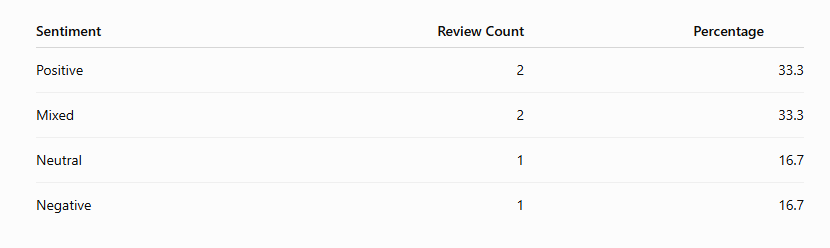

## Add a Business Interpretation

### Business Interpretation

The sentiment summary provides a high-level view of customer feedback. Positive reviews may indicate product strengths that should be maintained or emphasized in marketing. Mixed and negative reviews may identify product, usability, reliability, or customer-support issues that require further investigation.

The results should be treated as an initial customer-insights signal rather than a final business conclusion. A larger dataset and human review would be needed before making major product or operational decisions.


## Sample Output 1: Initial Customer Review Analysis

This sample demonstrates AI-powered sentiment classification, positive and negative feedback extraction, theme identification, customer concerns, and suggested business actions using the initial four-review dataset.

## Sample Output 2: Refined Multi-Review Analysis

This sample demonstrates the refined sentiment-analysis prompt using positive, negative, neutral, and mixed customer reviews. The analysis includes confidence levels, evidence, standardized review insights, sentiment counts, and prioritized business recommendations.


## Sample Output 3: Interactive Customer Review Analysis

This sample demonstrates the interactive workflow, where a user enters a customer review and receives an AI-generated sentiment classification, evidence-based feedback analysis, key themes, customer concerns, and a suggested business action.


## Sample Output 4: Batch Sentiment Summary

This sample demonstrates the batch-analysis workflow. Multiple customer reviews are analyzed, stored in a pandas DataFrame, and summarized using sentiment counts and percentages.

